In [1]:
pip install polars pyarrow torch torch_geometric networkx matplotlib

Note: you may need to restart the kernel to use updated packages.


## CELL 1 : Memory-Optimized Loading and Dynamic Initialization

In [1]:
import polars as pl
import torch
from torch_geometric.data import HeteroData
import networkx as nx
import matplotlib.pyplot as plt
import gc

PARQUET_PATH = "./processed/ml_ready_transactions.parquet"

# 1. Dynamically find 2 issuerCiks that ACTUALLY exist in the dataset
# We perform a fast, lazy scan to guarantee the CIKs exist without hardcoding.
print("Scanning dataset to dynamically select 2 companies...")
top_ciks = (
    pl.scan_parquet(PARQUET_PATH)
    .select("issuerCik")
    .drop_nulls()
    .group_by("issuerCik")
    .len()
    .sort("len", descending=True)
    .limit(2)
    .collect()
)
TARGET_CIKS = top_ciks["issuerCik"].to_list()
print(f"Selected issuerCiks: {TARGET_CIKS}")

# 2. Memory-efficient lazy query with robust date parsing
# We only project columns required by the schema and push predicates down to disk.
lazy_q = (
    pl.scan_parquet(PARQUET_PATH)
    .filter(pl.col("issuerCik").is_in(TARGET_CIKS))
    .drop_nulls(subset=["transactionDate", "rptOwnerCik", "securityTitle", "issuerCik"])
    .with_columns([
        # Parse transaction dates robustly from string format
        pl.col("transactionDate").str.to_datetime("%Y-%m-%d", strict=False).alias("transactionDate"),
        # Parse filing dates (BIGINT format like YYYYMMDD -> string -> datetime)
        pl.col("filingDate").cast(pl.Utf8).str.to_datetime("%Y%m%d", strict=False).alias("filingDate"),
        # Calculate derived transaction value and downcast to save RAM
        (pl.col("transactionShares") * pl.col("transactionPricePerShare")).cast(pl.Float32).alias("transactionValue")
    ])
    .sort("transactionDate")
)

df = lazy_q.collect()
print(f"Loaded {df.height} rows for the prototype graph.")
print(f"Estimated RAM: {df.estimated_size('mb'):.2f} MB")

Scanning dataset to dynamically select 2 companies...
Selected issuerCiks: [1794515, 1571996]
Loaded 32941317 rows for the prototype graph.
Estimated RAM: 3762.00 MB


## CELL 2: Leakage-Free Temporal Feature Engineering

In [3]:
# 1. Sort strictly chronologically, then by Insider
# This is crucial so that shift() operations perfectly reflect historical sequences without leakage.
df = df.sort(["rptOwnerCik", "transactionDate"])

# 2. Map Trade Direction: Acquired (A) = 1, Disposed (D) = -1
df = df.with_columns([
    pl.when(pl.col("transactionAcquiredDisposedCode") == "A").then(1)
      .when(pl.col("transactionAcquiredDisposedCode") == "D").then(-1)
      .otherwise(0).alias("trade_direction")
])
df = df.with_columns([
    (pl.col("transactionShares") * pl.col("trade_direction")).alias("signed_shares")
])

# 3. Compute strictly historical (t-1) cumulative features
# By appending .shift(1) over the rptOwnerCik partition, feature vectors for transaction 't' 
# are constructed solely from data available at 't-1'.
df = df.with_columns([
    pl.col("transactionDate").shift(1).over("rptOwnerCik").alias("prev_transactionDate"),
    pl.col("transactionCode").cum_count().shift(1).over("rptOwnerCik").fill_null(0).alias("historical_trade_frequency"),
    (pl.col("transactionAcquiredDisposedCode") == "A").cast(pl.Int32).cum_sum().shift(1).over("rptOwnerCik").fill_null(0).alias("cum_buys"),
    (pl.col("transactionAcquiredDisposedCode") == "D").cast(pl.Int32).cum_sum().shift(1).over("rptOwnerCik").fill_null(0).alias("cum_sells"),
    pl.col("transactionValue").cum_sum().shift(1).over("rptOwnerCik").fill_null(0.0).alias("cum_value"),
    pl.col("signed_shares").cum_sum().shift(1).over("rptOwnerCik").fill_null(0.0).cast(pl.Float32).alias("ownership_change")
])

# 4. Derived historical ratios & deltas
df = df.with_columns([
    (pl.col("transactionDate") - pl.col("prev_transactionDate")).dt.total_days().cast(pl.Float32).fill_null(0.0).alias("days_since_previous_trade"),
    (pl.col("cum_buys") / pl.col("historical_trade_frequency")).fill_nan(0.0).fill_null(0.0).alias("historical_buy_ratio"),
    (pl.col("cum_sells") / pl.col("historical_trade_frequency")).fill_nan(0.0).fill_null(0.0).alias("historical_sell_ratio"),
    (pl.col("cum_value") / pl.col("historical_trade_frequency")).fill_nan(0.0).fill_null(0.0).alias("historical_average_trade_value"),
])

# 5. Calculate Rolling Window Features (30, 90, 180 days)
# Using group_by_dynamic with closed="left" ensures trades occurring on the current day are completely excluded from the window.
for days in [30, 90, 180]:
    rolling_df = df.group_by_dynamic(
        "transactionDate",
        by="rptOwnerCik",
        every="1d",
        period=f"{days}d",
        closed="left" 
    ).agg(pl.len().alias(f"trades_{days}d"))
    
    # Left join back to the main DataFrame on EXACT dates and insider ID
    df = df.join(rolling_df, on=["rptOwnerCik", "transactionDate"], how="left").with_columns(
        pl.col(f"trades_{days}d").fill_null(0)
    )

# Re-sort strictly by time for the Temporal Graph
df = df.sort("transactionDate")
display(df.select(["rptOwnerCik", "transactionDate", "days_since_previous_trade", "trades_30d", "historical_trade_frequency"]).head(3))

C:\Users\minissha\AppData\Local\Temp\ipykernel_21952\2297165639.py:38: DeprecationWarning: the argument `by` for `DataFrame.group_by_dynamic` is deprecated. It was renamed to `group_by` in version 0.20.14.
  rolling_df = df.group_by_dynamic(


rptOwnerCik,transactionDate,days_since_previous_trade,trades_30d,historical_trade_frequency
i64,datetime[μs],f32,u32,u32
908724,2016-09-01 00:00:00,0.0,40,0
908724,2016-09-01 00:00:00,0.0,40,1
908724,2016-09-01 00:00:00,0.0,40,2


## CELL 3: PyTorch Geometric HeteroData Construction

In [4]:
data = HeteroData()

# 1. Create Composite Security Key
# A 'Common Stock' issued by Microsoft is entirely different from a 'Common Stock' issued by Apple.
df = df.with_columns(
    (pl.col("issuerCik").cast(pl.Utf8) + "_" + pl.col("securityTitle")).alias("composite_security_id")
)

# 2. Extract Unique Entities & Create Continuous Index Mappings
unique_insiders = df["rptOwnerCik"].unique().to_list()
unique_companies = df["issuerCik"].unique().to_list()
unique_securities = df["composite_security_id"].unique().to_list()

insider_map = {idx: i for i, idx in enumerate(unique_insiders)}
company_map = {idx: i for i, idx in enumerate(unique_companies)}
security_map = {idx: i for i, idx in enumerate(unique_securities)}

data['Insider'].num_nodes = len(unique_insiders)
data['Company'].num_nodes = len(unique_companies)
data['Security'].num_nodes = len(unique_securities)

# 3. Build Static Edge: Insider -> associated_with -> Company
# Keeps distinct role relationships as they change over time rather than arbitrary `.unique(keep="first")`
df_assoc = df.select(["rptOwnerCik", "issuerCik", "isDirector", "isOfficer", "isTenPercentOwner"]).unique()
src_assoc = [insider_map[x] for x in df_assoc["rptOwnerCik"].to_list()]
dst_assoc = [company_map[x] for x in df_assoc["issuerCik"].to_list()]

data['Insider', 'associated_with', 'Company'].edge_index = torch.tensor([src_assoc, dst_assoc], dtype=torch.long)
data['Insider', 'associated_with', 'Company'].edge_attr = torch.tensor(
    df_assoc.select(["isDirector", "isOfficer", "isTenPercentOwner"]).fill_null(0).to_numpy(), 
    dtype=torch.float32
)

# 4. Build Static Edge: Company -> issues -> Security
df_issues = df.select(["issuerCik", "composite_security_id"]).unique()
src_issues = [company_map[x] for x in df_issues["issuerCik"].to_list()]
dst_issues = [security_map[x] for x in df_issues["composite_security_id"].to_list()]
data['Company', 'issues', 'Security'].edge_index = torch.tensor([src_issues, dst_issues], dtype=torch.long)

# 5. Build Temporal Edge: Insider -> trades -> Security
# PRESERVES EVERY EVENT (Duplicates are not collapsed)
src_trades = [insider_map[x] for x in df["rptOwnerCik"].to_list()]
dst_trades = [security_map[x] for x in df["composite_security_id"].to_list()]
timestamps = df["transactionDate"].dt.timestamp("ms").fill_null(0).to_list()

data['Insider', 'trades', 'Security'].edge_index = torch.tensor([src_trades, dst_trades], dtype=torch.long)
data['Insider', 'trades', 'Security'].time = torch.tensor(timestamps, dtype=torch.long)

# Encode categorical variables for the tensor
df = df.with_columns([
    pl.col("transactionCode").cast(pl.Categorical).to_physical().cast(pl.Float32).alias("transactionCode_encoded"),
    pl.col("directOrIndirectOwnership").cast(pl.Categorical).to_physical().cast(pl.Float32).alias("ownership_encoded"),
    pl.col("filingDate").dt.timestamp("ms").cast(pl.Float32).alias("filing_timestamp")
])

trade_feature_cols = [
    "transactionCode_encoded", "transactionShares", "transactionPricePerShare", "transactionValue",
    "ownership_encoded", "filing_timestamp", "days_since_previous_trade", "trades_30d", "trades_90d", 
    "trades_180d", "historical_trade_frequency", "historical_buy_ratio", "historical_sell_ratio", 
    "historical_average_trade_value", "ownership_change"
]

data['Insider', 'trades', 'Security'].edge_attr = torch.tensor(
    df.select(trade_feature_cols).fill_null(0.0).to_numpy(),
    dtype=torch.float32
)

# Clean up memory
del df_assoc, df_issues
gc.collect()

# Print clear summary
print(f"\n--- Graph Summary ---")
print(f"Nodes: {data.num_nodes} (Insiders: {len(unique_insiders)}, Companies: {len(unique_companies)}, Securities: {len(unique_securities)})")
print(f"Edges: {data.num_edges} (Trades: {len(src_trades)}, Associations: {len(src_assoc)}, Issues: {len(src_issues)})")
print(f"Trade Feature Dimension: {data['Insider', 'trades', 'Security'].edge_attr.shape[1]}")

NameError: name 'HeteroData' is not defined

In [1]:
import gc
gc.collect()

23

## CELL 4: Clean Structural Visualization & Timeline

In [2]:
# 1. Structural Visualization (Aggregates edges to prevent overlapping spaghetti)
G_struct = nx.DiGraph()
vis_limit = 10 # Cap visual size

for i in range(min(vis_limit, len(src_assoc))):
    insider = f"I_{src_assoc[i]}"
    company = f"C_{dst_assoc[i]}"
    G_struct.add_node(insider, type='Insider', color='lightblue')
    G_struct.add_node(company, type='Company', color='lightgreen')
    G_struct.add_edge(insider, company, label='associated')

for i in range(min(vis_limit, len(src_issues))):
    company = f"C_{src_issues[i]}"
    security = f"S_{dst_issues[i]}"
    G_struct.add_node(company, type='Company', color='lightgreen')
    G_struct.add_node(security, type='Security', color='salmon')
    G_struct.add_edge(company, security, label='issues')

# Aggregate trades purely for structural visualization
trade_counts = df.group_by(["rptOwnerCik", "composite_security_id"]).len()
for row in trade_counts.head(vis_limit).iter_rows(named=True):
    insider = f"I_{insider_map[row['rptOwnerCik']]}"
    sec = f"S_{security_map[row['composite_security_id']]}"
    if G_struct.has_node(insider) and G_struct.has_node(sec):
        G_struct.add_edge(insider, sec, label=f"trades ({row['len']}x)")

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G_struct, seed=42)
node_colors = [nx.get_node_attributes(G_struct, 'color').get(n, 'gray') for n in G_struct.nodes()]

nx.draw(G_struct, pos, with_labels=True, node_color=node_colors, node_size=1500, font_size=8, font_weight='bold', edge_color='gray')
nx.draw_networkx_edge_labels(G_struct, pos, edge_labels=nx.get_edge_attributes(G_struct, 'label'), font_size=7)
plt.title("Aggregated Graph Structure (Prototype)")
plt.show()

# 2. Temporal Timeline Visualization (Tracking distinct temporal events)
plt.figure(figsize=(12, 4))
timeline_df = df.select(["transactionDate", "transactionValue"]).drop_nulls().sort("transactionDate")
if timeline_df.height > 1000:
    timeline_df = timeline_df.sample(1000).sort("transactionDate") # Sample to prevent plotting freeze
    
plt.scatter(timeline_df["transactionDate"].to_list(), timeline_df["transactionValue"].to_list(), alpha=0.5, s=15, c='purple', edgecolors='none')
plt.title(f"Temporal Trade Events Timeline (n={timeline_df.height})")
plt.xlabel("Transaction Date")
plt.ylabel("Transaction Value ($)")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

# --- Scalability Explanation ---
print("\n--- Scaling to the Full Dataset ---")
print("1. Out-of-Core Processing: We will replace df.collect() with chunked iteration or Dask, mapping entities dynamically without maintaining a massive mapping dictionary in RAM.")
print("2. Memory Management: Trade nodes will not be retained in pandas/polars formats. The processed tensors will be written natively to disk-backed formats (e.g., PyG's on-disk dataset format).")
print("3. Temporal Batches: For training, PyTorch Geometric's TemporalDataLoader dynamically constructs chronological neighbor subgraphs in minibatches. The GPU will only ever 'see' a few thousand edges at a time, allowing continuous ingestion of the 600M edge dataset.")

NameError: name 'nx' is not defined

## CELL 5: Visualise Global Graph (Cross Pollination)

In [ ]:
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PARQUET_PATH = "./processed/ml_ready_transactions.parquet"

print("1. Searching for a 'Hub Insider' using lazy streaming...")

# Find an insider connected to multiple companies using Polars streaming engine
hub_insider_df = (
    pl.scan_parquet(PARQUET_PATH)
    .select(["rptOwnerCik", "issuerCik"])
    .drop_nulls()
    .unique()
    .group_by("rptOwnerCik")
    .agg(pl.col("issuerCik").n_unique().alias("company_count"))
    .filter(pl.col("company_count") >= 3)
    .sort("company_count", descending=True)
    .limit(1)
    .collect(engine="streaming")
)

if hub_insider_df.height == 0:
    raise ValueError("No insider found connected to >= 3 companies.")

HUB_INSIDER = hub_insider_df["rptOwnerCik"][0]

# Retrieve up to 3 target companies associated with the Hub Insider
target_companies = (
    pl.scan_parquet(PARQUET_PATH)
    .filter(pl.col("rptOwnerCik") == HUB_INSIDER)
    .select("issuerCik")
    .drop_nulls()
    .unique()
    .limit(3)
    .collect(engine="streaming")
)["issuerCik"].to_list()

print(f"Found Hub Insider: {HUB_INSIDER}")
print(f"Extracting global subgraph for associated Companies: {target_companies}")

# 2. Extract the subgraph for target companies using streaming execution
df_subgraph = (
    pl.scan_parquet(PARQUET_PATH)
    .filter(pl.col("issuerCik").is_in(target_companies))
    .select(["rptOwnerCik", "issuerCik", "securityTitle"])
    .drop_nulls()
    .with_columns(
        (pl.col("issuerCik").cast(pl.Utf8) + "_" + pl.col("securityTitle")).alias("composite_security_id")
    )
    .collect(engine="streaming")
)

# 3. Build the NetworkX Graph
G_global = nx.DiGraph()

# Add Edges: Insider -> Company
df_assoc = df_subgraph.select(["rptOwnerCik", "issuerCik"]).unique()
for row in df_assoc.iter_rows(named=True):
    insider = f"I_{row['rptOwnerCik']}"
    company = f"C_{row['issuerCik']}"
    
    is_hub = row['rptOwnerCik'] == HUB_INSIDER
    node_color = 'red' if is_hub else 'lightblue'
    node_size = 800 if is_hub else 300
    
    G_global.add_node(insider, type='Insider', color=node_color, size=node_size)
    G_global.add_node(company, type='Company', color='lightgreen', size=600)
    G_global.add_edge(insider, company, label='associated')

# Add Edges: Company -> Security
df_issues = df_subgraph.select(["issuerCik", "composite_security_id"]).unique()
for row in df_issues.iter_rows(named=True):
    company = f"C_{row['issuerCik']}"
    security = f"S_{row['composite_security_id'][:10]}..."
    G_global.add_node(security, type='Security', color='salmon', size=400)
    G_global.add_edge(company, security, label='issues')

# Add Edges: Insider -> Security (Aggregated trades)
df_trades = df_subgraph.group_by(["rptOwnerCik", "composite_security_id"]).len()
for row in df_trades.iter_rows(named=True):
    insider = f"I_{row['rptOwnerCik']}"
    security = f"S_{row['composite_security_id'][:10]}..."
    if G_global.has_node(insider) and G_global.has_node(security):
        G_global.add_edge(insider, security, label='trades')

# 4. Filter the graph around the Hub Insider neighborhood
hub_node = f"I_{HUB_INSIDER}"
if hub_node in G_global:
    neighbors = set(nx.all_neighbors(G_global, hub_node))
    neighbors.add(hub_node)

    subgraph_nodes = set(neighbors)
    for node in neighbors:
        if G_global.nodes[node].get('type') == 'Company':
            subgraph_nodes.update(nx.all_neighbors(G_global, node))

    G_clean = G_global.subgraph(subgraph_nodes)
else:
    G_clean = G_global

# 5. Plot the Global Subgraph Example
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_clean, k=0.5, seed=42)

colors = [nx.get_node_attributes(G_clean, 'color').get(n, 'gray') for n in G_clean.nodes()]
sizes = [nx.get_node_attributes(G_clean, 'size').get(n, 300) for n in G_clean.nodes()]

nx.draw(G_clean, pos, with_labels=True, node_color=colors, node_size=sizes, font_size=8, font_weight='bold', edge_color='gray', alpha=0.9)

# Draw edge labels
edge_labels = nx.get_edge_attributes(G_clean, 'label')
nx.draw_networkx_edge_labels(G_clean, pos, edge_labels=edge_labels, font_size=7)

# Custom legend
legend_handles = [
    mpatches.Patch(color='red', label='Hub Insider (Cross-Company)'),
    mpatches.Patch(color='lightblue', label='Standard Insider'),
    mpatches.Patch(color='lightgreen', label='Company'),
    mpatches.Patch(color='salmon', label='Security')
]
plt.legend(handles=legend_handles, loc='upper left')

plt.title("Example of Global Graph Cross-Pollination", fontsize=14)
plt.show()

In [ ]:
# Quick, cheap sanity check before the heavy cell — confirms row count
# and on-disk size without loading anything into memory.
import polars as pl
from pathlib import Path

p = Path("./processed/ml_ready_transactions.parquet")
print(f"File size: {p.stat().st_size / (1024**2):.1f} MB")
print(f"Row count: {pl.scan_parquet(p).select(pl.len()).collect().item():,}")
print(f"Columns:   {pl.scan_parquet(p).collect_schema().names()}")

## CELL 6: Temporal Hetero Graph

In [ ]:
"""
Build and visualize a temporal heterogeneous graph from insider-trading
transaction data.

Pipeline:
  1. Polars  -> fast, lazy, memory-efficient load + filter to top-5 companies
  2. PyTorch Geometric -> HeteroData graph (Insider / Company / Security nodes;
     associated_with / issues / trades edges)
  3. NetworkX -> a readable static visualization, with the (very high volume)
     temporal `trades` edges aggregated per (insider, security) pair instead
     of drawn one-per-transaction.

Input parquet is expected at ./processed/ml_ready_transactions.parquet with
columns: issuerCik, rptOwnerCik, securityTitle, transactionDate, isDirector,
isOfficer, isTenPercentOwner.
"""

from __future__ import annotations

from pathlib import Path

import numpy as np
import polars as pl
import gc
import torch
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch_geometric.data import HeteroData

PARQUET_PATH = Path("./processed/ml_ready_transactions.parquet")
TOP_N_COMPANIES = 5


# --------------------------------------------------------------------------
# 1. Load + filter (Polars, lazy)
# --------------------------------------------------------------------------
def load_top_companies(path: Path, top_n: int) -> pl.DataFrame:
    """Scan the parquet lazily, find the top-N companies by transaction
    count, then materialize only the rows/columns actually needed.
    The full file is never fully collected into memory."""
    lf = pl.scan_parquet(path, low_memory=True)

    # Only the columns build_id_maps / build_hetero_data / visualize touch.
    # Selecting these BEFORE collect() lets Polars push the projection down
    # to the parquet reader, instead of materializing every raw column.
    needed_cols = [
        "rptOwnerCik", "issuerCik", "securityTitle", "transactionDate",
        "isDirector", "isOfficer", "isTenPercentOwner",
    ]

    top_ciks = (
        lf.group_by("issuerCik")
        .agg(pl.len().alias("n_transactions"))
        .sort("n_transactions", descending=True)
        .head(top_n)
        .collect(engine="streaming")   # avoid pulling the whole table in-memory
        .get_column("issuerCik")
        .to_list()
    )

    df = (
        lf.filter(pl.col("issuerCik").is_in(top_ciks))
        .select(needed_cols)           # <-- column projection: big memory win
        .with_columns(
            pl.col("transactionDate").str.to_datetime(strict=False).alias("transactionDate"),
            (pl.col("issuerCik").cast(pl.Utf8) + "_" + pl.col("securityTitle")).alias("securityKey"),
        )
        .sort(["rptOwnerCik", "transactionDate"])
        .collect(engine="streaming")   # avoid pulling the whole table in-memory
    )

    gc.collect()
    return df, top_ciks


def build_id_maps(df: pl.DataFrame) -> dict[str, dict]:
    insider_ids = df.get_column("rptOwnerCik").unique().sort().to_list()
    company_ids = df.get_column("issuerCik").unique().sort().to_list()
    security_ids = df.get_column("securityKey").unique().sort().to_list()

    return {
        "insider": {v: i for i, v in enumerate(insider_ids)},
        "company": {v: i for i, v in enumerate(company_ids)},
        "security": {v: i for i, v in enumerate(security_ids)},
    }


# --------------------------------------------------------------------------
# 3. Build the HeteroData object
# --------------------------------------------------------------------------
def build_hetero_data(df: pl.DataFrame, id_maps: dict[str, dict]) -> HeteroData:
    """NOTE on memory: id lookups are done as Polars joins (vectorized,
    columnar) and tensors are built via numpy + torch.from_numpy (zero-copy).
    The previous version used `.to_list()` + a Python dict-comprehension for
    the 64.7M-row `trades` edges -- that materializes ~65M individual Python
    int/str objects (the securityKey strings alone are several GB) on top of
    the already-resident df, which is what was killing the kernel."""
    data = HeteroData()

    n_insiders = len(id_maps["insider"])
    n_companies = len(id_maps["company"])
    n_securities = len(id_maps["security"])

    # Small lookup frames (a few hundred rows) used to join integer indices
    # onto the big trades table instead of python dict-comprehensions.
    insider_idx_df = pl.DataFrame(
        {"rptOwnerCik": list(id_maps["insider"].keys()), "insider_idx": list(id_maps["insider"].values())}
    ).with_columns(pl.col("insider_idx").cast(pl.Int64))
    company_idx_df = pl.DataFrame(
        {"issuerCik": list(id_maps["company"].keys()), "company_idx": list(id_maps["company"].values())}
    ).with_columns(pl.col("company_idx").cast(pl.Int64))
    security_idx_df = pl.DataFrame(
        {"securityKey": list(id_maps["security"].keys()), "security_idx": list(id_maps["security"].values())}
    ).with_columns(pl.col("security_idx").cast(pl.Int64))

    # --- minimal node features -------------------------------------------------
    insider_roles = (
        df.group_by("rptOwnerCik")
        .agg(
            pl.col("isDirector").max(),
            pl.col("isOfficer").max(),
            pl.col("isTenPercentOwner").max(),
        )
        .sort("rptOwnerCik")
    )
    data["insider"].x = torch.from_numpy(
        insider_roles.select(["isDirector", "isOfficer", "isTenPercentOwner"]).to_numpy().astype(np.float32)
    )
    data["insider"].raw_id = insider_roles.get_column("rptOwnerCik").to_list()

    data["company"].x = torch.ones((n_companies, 1), dtype=torch.float)
    data["company"].raw_id = sorted(id_maps["company"], key=id_maps["company"].get)

    data["security"].x = torch.arange(n_securities, dtype=torch.float).unsqueeze(1)
    data["security"].raw_id = sorted(id_maps["security"], key=id_maps["security"].get)

    # --- associated_with: Insider -> Company (deduped, is* cols as edge features) ---
    assoc = (
        df.group_by(["rptOwnerCik", "issuerCik"])
        .agg(
            pl.col("isDirector").max(),
            pl.col("isOfficer").max(),
            pl.col("isTenPercentOwner").max(),
        )
        .join(insider_idx_df, on="rptOwnerCik", how="left")
        .join(company_idx_df, on="issuerCik", how="left")
    )
    edge_index_np = assoc.select(["insider_idx", "company_idx"]).to_numpy().T.astype(np.int64)
    data["insider", "associated_with", "company"].edge_index = torch.from_numpy(edge_index_np)
    data["insider", "associated_with", "company"].edge_attr = torch.from_numpy(
        assoc.select(["isDirector", "isOfficer", "isTenPercentOwner"]).to_numpy().astype(np.float32)
    )

    # --- issues: Company -> Security (deduped) ---
    issues = (
        df.select(["issuerCik", "securityKey"]).unique()
        .join(company_idx_df, on="issuerCik", how="left")
        .join(security_idx_df, on="securityKey", how="left")
    )
    edge_index_np = issues.select(["company_idx", "security_idx"]).to_numpy().T.astype(np.int64)
    data["company", "issues", "security"].edge_index = torch.from_numpy(edge_index_np)

    # --- trades: Insider -> Security (temporal, one edge per transaction) ---
    # This is the 64.7M-row edge type -- everything below stays vectorized
    # (Polars join -> numpy -> torch.from_numpy), never touching Python
    # lists/dicts per-row.
    trades = (
        df.filter(pl.col("transactionDate").is_not_null())
        .select(["rptOwnerCik", "securityKey", "transactionDate"])
        .sort("transactionDate")
        .join(insider_idx_df, on="rptOwnerCik", how="left")
        .join(security_idx_df, on="securityKey", how="left")
        .with_columns((pl.col("transactionDate").cast(pl.Int64) // 1_000_000).alias("edge_time_s"))  # ns -> s
    )
    edge_index_np = trades.select(["insider_idx", "security_idx"]).to_numpy().T.astype(np.int64)
    data["insider", "trades", "security"].edge_index = torch.from_numpy(edge_index_np)
    data["insider", "trades", "security"].edge_time = torch.from_numpy(
        trades.get_column("edge_time_s").to_numpy().astype(np.int64)
    )

    del trades
    gc.collect()

    return data


# --------------------------------------------------------------------------
# 4. Visualization (trades aggregated per insider-security pair)
# --------------------------------------------------------------------------
def visualize(
    assoc_small: pl.DataFrame,
    issues_small: pl.DataFrame,
    trades_agg_small: pl.DataFrame,
    id_maps: dict[str, dict],
    top_ciks: list,
) -> None:
    """Draws the AGGREGATED structural graph only. Takes three small,
    already-aggregated Polars frames (computed in main(), BEFORE the huge
    raw `df` is freed) instead of the full 64M-row transaction table --
    that's what was blowing up RAM and killing the kernel."""
    G = nx.MultiDiGraph()

    for raw_id in id_maps["insider"]:
        G.add_node(("insider", raw_id), ntype="insider", label=f"Insider\n{raw_id}")
    for raw_id in id_maps["company"]:
        G.add_node(("company", raw_id), ntype="company", label=f"Company\nCIK {raw_id}")
    for raw_id in id_maps["security"]:
        title = raw_id.split("_", 1)[1] if "_" in raw_id else raw_id
        G.add_node(("security", raw_id), ntype="security", label=title)

    for r in assoc_small.iter_rows(named=True):
        G.add_edge(("insider", r["rptOwnerCik"]), ("company", r["issuerCik"]), etype="associated_with")

    for r in issues_small.iter_rows(named=True):
        G.add_edge(("company", r["issuerCik"]), ("security", r["securityKey"]), etype="issues")

    # Already aggregated: one drawn edge per (insider, security) pair,
    # weighted/labelled by transaction count.
    for r in trades_agg_small.iter_rows(named=True):
        G.add_edge(
            ("insider", r["rptOwnerCik"]),
            ("security", r["securityKey"]),
            etype="trades",
            weight=r["n_trades"],
        )

    node_colors = {"insider": "#4C72B0", "company": "#55A868", "security": "#C44E52"}
    edge_colors = {"associated_with": "#4C72B0", "issues": "#55A868", "trades": "#999999"}

    pos = nx.spring_layout(G, seed=3, k=1.1)

    fig, ax = plt.subplots(figsize=(12, 9))
    for ntype, color in node_colors.items():
        nodes = [n for n, d in G.nodes(data=True) if d["ntype"] == ntype]
        size = 800 if ntype != "security" else 600
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=color, node_size=size,
                                label=ntype.capitalize(), ax=ax, alpha=0.9)

    for etype, color in edge_colors.items():
        edges = [(u, v, d) for u, v, d in G.edges(data=True) if d["etype"] == etype]
        if etype == "trades":
            # width scales with aggregated transaction count
            widths = [0.4 + 0.15 * d["weight"] for _, _, d in edges]
        else:
            widths = [1.6] * len(edges)
        nx.draw_networkx_edges(
            G, pos,
            edgelist=[(u, v) for u, v, _ in edges],
            width=widths, edge_color=color, alpha=0.6, arrows=True,
            arrowsize=10, connectionstyle="arc3,rad=0.05", ax=ax,
        )

    labels = {n: d["label"] for n, d in G.nodes(data=True)}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, ax=ax)

    node_handles = [mpatches.Patch(color=c, label=t.capitalize()) for t, c in node_colors.items()]
    edge_handles = [
        mpatches.Patch(color=edge_colors["associated_with"], label="associated_with"),
        mpatches.Patch(color=edge_colors["issues"], label="issues"),
        mpatches.Patch(color=edge_colors["trades"], label="trades (width = # transactions)"),
    ]
    ax.legend(handles=node_handles + edge_handles, loc="upper left", fontsize=8, framealpha=0.9)
    ax.set_title(f"Temporal heterogeneous graph — top {len(top_ciks)} companies by transaction count")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("temporal_hetero_graph.png", dpi=180)
    plt.show()


# --------------------------------------------------------------------------
def main() -> None:
    df, top_ciks = load_top_companies(PARQUET_PATH, TOP_N_COMPANIES)
    print(f"Loaded {df.height:,} transactions across top {len(top_ciks)} companies: {top_ciks}")

    id_maps = build_id_maps(df)
    print(f"Nodes -> insiders: {len(id_maps['insider'])}, "
          f"companies: {len(id_maps['company'])}, securities: {len(id_maps['security'])}")

    data = build_hetero_data(df, id_maps)
    print(data)

    # Compute the (tiny) aggregates visualize() needs BEFORE freeing df.
    # These are bounded by (#insiders x #companies) / (#companies x #securities)
    # / (#insiders x #securities) -- a few hundred rows, not 64M.
    assoc_small = df.select(["rptOwnerCik", "issuerCik"]).unique()
    issues_small = df.select(["issuerCik", "securityKey"]).unique()
    trades_agg_small = df.group_by(["rptOwnerCik", "securityKey"]).agg(pl.len().alias("n_trades"))

    # Free the big (64M-row) DataFrame + the raw parquet read before plotting --
    # this, combined with the already-built HeteroData tensors, is what was
    # pushing peak memory over the edge and killing the kernel.
    del df
    gc.collect()

    visualize(assoc_small, issues_small, trades_agg_small, id_maps, top_ciks)


if __name__ == "__main__":
    main()

## CELL 7: Companies as Nodes

In [ ]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import polars as pl
import torch
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch_geometric.data import HeteroData
import gc

PARQUET_PATH = Path("./processed/ml_ready_transactions.parquet")
TOP_N_COMPANIES = 2

def load_top_companies(path: Path, top_n: int) -> pl.DataFrame:
    lf = pl.scan_parquet(path, low_memory=True)
    top_ciks = (
        lf.drop_nulls(subset=["issuerCik"])
        .group_by("issuerCik")
        .agg(pl.len().alias("n_transactions"))
        .sort("n_transactions", descending=True)
        .head(top_n)
        .collect(engine="streaming")
        .get_column("issuerCik")
        .to_list()
    )
    df = (
        lf.filter(pl.col("issuerCik").is_in(top_ciks))
        .drop_nulls(subset=["transactionDate", "rptOwnerCik", "securityTitle", "issuerCik"])
        .with_columns(
            pl.col("transactionDate").str.to_datetime("%Y-%m-%d", strict=False).alias("transactionDate"),
            (pl.col("issuerCik").cast(pl.Utf8) + "_" + pl.col("securityTitle")).alias("securityKey"),
        )
        .sort(["rptOwnerCik", "transactionDate"])
        .collect(engine="streaming")
    )
    return df, top_ciks

def build_id_maps(df: pl.DataFrame) -> dict[str, dict]:
    insider_ids = df.get_column("rptOwnerCik").unique().sort().to_list()
    company_ids = df.get_column("issuerCik").unique().sort().to_list()
    security_ids = df.get_column("securityKey").unique().sort().to_list()
    return {
        "insider": {v: i for i, v in enumerate(insider_ids)},
        "company": {v: i for i, v in enumerate(company_ids)},
        "security": {v: i for i, v in enumerate(security_ids)},
    }

def build_hetero_data(df: pl.DataFrame, id_maps: dict[str, dict]) -> HeteroData:
    data = HeteroData()
    n_insiders = len(id_maps["insider"])
    n_companies = len(id_maps["company"])
    n_securities = len(id_maps["security"])

    insider_idx_df = pl.DataFrame(
        {"rptOwnerCik": list(id_maps["insider"].keys()), "insider_idx": list(id_maps["insider"].values())}
    ).with_columns(pl.col("insider_idx").cast(pl.Int64))
    company_idx_df = pl.DataFrame(
        {"issuerCik": list(id_maps["company"].keys()), "company_idx": list(id_maps["company"].values())}
    ).with_columns(pl.col("company_idx").cast(pl.Int64))
    security_idx_df = pl.DataFrame(
        {"securityKey": list(id_maps["security"].keys()), "security_idx": list(id_maps["security"].values())}
    ).with_columns(pl.col("security_idx").cast(pl.Int64))

    insider_roles = (
        df.group_by("rptOwnerCik")
        .agg(pl.col("isDirector").max().fill_null(0), pl.col("isOfficer").max().fill_null(0),
             pl.col("isTenPercentOwner").max().fill_null(0))
        .sort("rptOwnerCik")
    )
    data["insider"].x = torch.from_numpy(
        insider_roles.select(["isDirector", "isOfficer", "isTenPercentOwner"]).to_numpy().astype(np.float32)
    )
    data["company"].x = torch.ones((n_companies, 1), dtype=torch.float32)
    data["security"].x = torch.arange(n_securities, dtype=torch.float32).unsqueeze(1)

    assoc = (
        df.group_by(["rptOwnerCik", "issuerCik"])
        .agg(pl.col("isDirector").max().fill_null(0), pl.col("isOfficer").max().fill_null(0),
             pl.col("isTenPercentOwner").max().fill_null(0))
        .join(insider_idx_df, on="rptOwnerCik", how="left")
        .join(company_idx_df, on="issuerCik", how="left")
    )
    data["insider", "associated_with", "company"].edge_index = torch.from_numpy(
        assoc.select(["insider_idx", "company_idx"]).to_numpy().T.astype(np.int64)
    )
    data["insider", "associated_with", "company"].edge_attr = torch.from_numpy(
        assoc.select(["isDirector", "isOfficer", "isTenPercentOwner"]).to_numpy().astype(np.float32)
    )

    issues = (
        df.select(["issuerCik", "securityKey"]).unique()
        .join(company_idx_df, on="issuerCik", how="left")
        .join(security_idx_df, on="securityKey", how="left")
    )
    data["company", "issues", "security"].edge_index = torch.from_numpy(
        issues.select(["company_idx", "security_idx"]).to_numpy().T.astype(np.int64)
    )

    trades = (
        df.filter(pl.col("transactionDate").is_not_null())
        .select(["rptOwnerCik", "securityKey", "transactionDate"])
        .sort("transactionDate")
        .join(insider_idx_df, on="rptOwnerCik", how="left")
        .join(security_idx_df, on="securityKey", how="left")
        .with_columns((pl.col("transactionDate").cast(pl.Int64) // 1_000_000).alias("edge_time_s"))
    )
    data["insider", "trades", "security"].edge_index = torch.from_numpy(
        trades.select(["insider_idx", "security_idx"]).to_numpy().T.astype(np.int64)
    )
    data["insider", "trades", "security"].time = torch.from_numpy(
        trades.get_column("edge_time_s").to_numpy().astype(np.int64)
    )
    del trades
    gc.collect()
    return data

def visualize(assoc_small: pl.DataFrame, issues_small: pl.DataFrame, trades_agg_small: pl.DataFrame,
              id_maps: dict[str, dict], top_ciks: list, vis_limit: int) -> None:
    G = nx.MultiDiGraph()
    insider_sample = list(id_maps["insider"].keys())[:vis_limit]

    for raw_id in insider_sample:
        G.add_node(("insider", raw_id), ntype="insider", label=f"I_{raw_id}")
    for raw_id in id_maps["company"]:
        G.add_node(("company", raw_id), ntype="company", label=f"C_{raw_id}")
    for raw_id in id_maps["security"]:
        title = raw_id.split("_", 1)[1] if "_" in raw_id else raw_id
        G.add_node(("security", raw_id), ntype="security", label=title[:10])

    for r in assoc_small.iter_rows(named=True):
        G.add_edge(("insider", r["rptOwnerCik"]), ("company", r["issuerCik"]), etype="associated_with")

    for r in issues_small.iter_rows(named=True):
        G.add_edge(("company", r["issuerCik"]), ("security", r["securityKey"]), etype="issues")

    for r in trades_agg_small.iter_rows(named=True):
        G.add_edge(("insider", r["rptOwnerCik"]), ("security", r["securityKey"]), etype="trades", weight=r["n_trades"])

    isolated_nodes = [node for node, degree in dict(G.degree()).items() if degree == 0]
    G.remove_nodes_from(isolated_nodes)

    node_colors = {"insider": "#4C72B0", "company": "#55A868", "security": "#C44E52"}
    edge_colors = {"associated_with": "#4C72B0", "issues": "#55A868", "trades": "#999999"}

    plt.figure(figsize=(10, 7))
    pos = nx.spring_layout(G, seed=42, k=0.8)

    for ntype, color in node_colors.items():
        nodes = [n for n, d in G.nodes(data=True) if d["ntype"] == ntype]
        size = 800 if ntype != "security" else 400
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=color, node_size=size, alpha=0.9)

    for etype, color in edge_colors.items():
        edges = [(u, v, d) for u, v, d in G.edges(data=True) if d["etype"] == etype]
        widths = [0.5 + 0.1 * d.get("weight", 1) for _, _, d in edges] if etype == "trades" else [1.5] * len(edges)
        nx.draw_networkx_edges(
            G, pos, edgelist=[(u, v) for u, v, _ in edges],
            width=widths, edge_color=color, alpha=0.6, arrows=True, connectionstyle="arc3,rad=0.1"
        )

    labels = {n: d["label"] for n, d in G.nodes(data=True)}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=7)

    handles = [mpatches.Patch(color=c, label=t.capitalize()) for t, c in node_colors.items()]
    plt.legend(handles=handles, loc="upper left", fontsize=8)
    plt.title(f"Temporal Heterogeneous Graph (Sample of {vis_limit} Insiders)")
    plt.axis("off")
    plt.show()
# --------------------------------------------------------------------------
# Execute Pipeline (fully lazy — never materializes the full 32.9M rows)
# --------------------------------------------------------------------------
top_ciks = (
    pl.scan_parquet(PARQUET_PATH, low_memory=True)
    .drop_nulls(subset=["issuerCik"])
    .group_by("issuerCik")
    .agg(pl.len().alias("n_transactions"))
    .sort("n_transactions", descending=True)
    .head(TOP_N_COMPANIES)
    .collect(engine="streaming")
    .get_column("issuerCik")
    .to_list()
)
print(f"Target companies: {top_ciks}")

lf = (
    pl.scan_parquet(PARQUET_PATH, low_memory=True)
    .filter(pl.col("issuerCik").is_in(top_ciks))
    .drop_nulls(subset=["transactionDate", "rptOwnerCik", "securityTitle", "issuerCik"])
    .with_columns(
        pl.col("transactionDate").str.to_datetime("%Y-%m-%d", strict=False).alias("transactionDate"),
        (pl.col("issuerCik").cast(pl.Utf8) + "_" + pl.col("securityTitle")).alias("securityKey"),
    )
)

insider_ids = lf.select("rptOwnerCik").unique().sort("rptOwnerCik").collect(engine="streaming").get_column("rptOwnerCik").to_list()
company_ids = lf.select("issuerCik").unique().sort("issuerCik").collect(engine="streaming").get_column("issuerCik").to_list()
security_ids = lf.select("securityKey").unique().sort("securityKey").collect(engine="streaming").get_column("securityKey").to_list()

id_maps = {
    "insider": {v: i for i, v in enumerate(insider_ids)},
    "company": {v: i for i, v in enumerate(company_ids)},
    "security": {v: i for i, v in enumerate(security_ids)},
}
print(f"insiders: {len(insider_ids)}, companies: {len(company_ids)}, securities: {len(security_ids)}")

vis_limit = 25
insider_sample = insider_ids[:vis_limit]

assoc_small = (
    lf.filter(pl.col("rptOwnerCik").is_in(insider_sample))
    .select(["rptOwnerCik", "issuerCik"]).unique()
    .collect(engine="streaming")
)
issues_small = (
    lf.select(["issuerCik", "securityKey"]).unique()
    .collect(engine="streaming")
)
trades_agg_small = (
    lf.filter(pl.col("rptOwnerCik").is_in(insider_sample))
    .group_by(["rptOwnerCik", "securityKey"])
    .agg(pl.len().alias("n_trades"))
    .collect(engine="streaming")
)

visualize(assoc_small, issues_small, trades_agg_small, id_maps, top_ciks, vis_limit)

Target companies: [1794515, 1571996]
insiders: 119, companies: 2, securities: 9


## CELL 8: Organized Graph of Cell 5

In [ ]:
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PARQUET_PATH = "./processed/ml_ready_transactions.parquet"

# 1. Locate the Hub Insider and their associated companies
hub_insider_df = (
    pl.scan_parquet(PARQUET_PATH)
    .select(["rptOwnerCik", "issuerCik"])
    .drop_nulls()
    .unique()
    .group_by("rptOwnerCik")
    .len()
    .filter(pl.col("len") >= 3)
    .sort("len", descending=True)
    .limit(1)
    .collect()
)
HUB_INSIDER = hub_insider_df["rptOwnerCik"][0]

target_companies = (
    pl.scan_parquet(PARQUET_PATH)
    .filter(pl.col("rptOwnerCik") == HUB_INSIDER)
    .select("issuerCik")
    .unique()
    .limit(3)
    .collect()
)["issuerCik"].to_list()

df_subgraph = (
    pl.scan_parquet(PARQUET_PATH)
    .filter(pl.col("issuerCik").is_in(target_companies))
    .select(["rptOwnerCik", "issuerCik", "securityTitle"])
    .drop_nulls()
    .with_columns(
        (pl.col("issuerCik").cast(pl.Utf8) + "_" + pl.col("securityTitle")).alias("composite_security_id")
    )
    .collect()
)

# 2. Build the Graph
G = nx.DiGraph()

# Add Companies
for cik in target_companies:
    G.add_node(f"C_{cik}", layer=1, type="company", label=f"Company\n{cik}")

# Add Securities
df_issues = df_subgraph.select(["issuerCik", "composite_security_id"]).unique()
for row in df_issues.iter_rows(named=True):
    comp = f"C_{row['issuerCik']}"
    sec = f"S_{row['composite_security_id']}"
    title = row["composite_security_id"].split("_", 1)[1][:12]
    G.add_node(sec, layer=2, type="security", label=f"{title}...")
    G.add_edge(comp, sec, etype="issues")

# Add Insiders (Sample up to 4 standard insiders + the Hub Insider to prevent clutter)
sample_insiders = (
    df_subgraph.filter(pl.col("rptOwnerCik") != HUB_INSIDER)["rptOwnerCik"]
    .unique()
    .head(4)
    .to_list()
)
all_insiders = [HUB_INSIDER] + sample_insiders

for rpt_cik in all_insiders:
    insider = f"I_{rpt_cik}"
    is_hub = (rpt_cik == HUB_INSIDER)
    G.add_node(
        insider,
        layer=0,
        type="hub_insider" if is_hub else "standard_insider",
        label=f"★ HUB INSIDER\n{rpt_cik}" if is_hub else f"Insider\n{rpt_cik}"
    )

# Add Associations & Trades
df_assoc = df_subgraph.filter(pl.col("rptOwnerCik").is_in(all_insiders)).select(["rptOwnerCik", "issuerCik"]).unique()
for row in df_assoc.iter_rows(named=True):
    G.add_edge(f"I_{row['rptOwnerCik']}", f"C_{row['issuerCik']}", etype="associated_with")

df_trades = df_subgraph.filter(pl.col("rptOwnerCik").is_in(all_insiders)).select(["rptOwnerCik", "composite_security_id"]).unique()
for row in df_trades.iter_rows(named=True):
    sec = f"S_{row['composite_security_id']}"
    if G.has_node(sec):
        G.add_edge(f"I_{row['rptOwnerCik']}", sec, etype="trades")

# 3. Compute Clean 3-Column Coordinates (Multipartite Layout)
pos = nx.multipartite_layout(G, subset_key="layer", scale=2.5)

# Separate node types for clean styling
hub_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "hub_insider"]
std_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "standard_insider"]
comp_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "company"]
sec_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "security"]

# Separate edge types
assoc_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("etype") == "associated_with"]
issue_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("etype") == "issues"]
trade_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("etype") == "trades"]

# 4. Render the Figure
fig, ax = plt.subplots(figsize=(14, 8))

# Draw Nodes
nx.draw_networkx_nodes(G, pos, nodelist=hub_nodes, node_color="#E63946", node_size=2800, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=std_nodes, node_color="#457B9D", node_size=1800, alpha=0.85, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=comp_nodes, node_color="#2A9D8F", node_size=2200, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=sec_nodes, node_color="#E76F51", node_size=1600, alpha=0.85, ax=ax)

# Draw Labels
labels = {n: d.get("label", n) for n, d in G.nodes(data=True)}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight="bold", font_color="white", ax=ax)

# Draw Edges with Clean Curves
nx.draw_networkx_edges(G, pos, edgelist=assoc_edges, edge_color="#2A9D8F", width=2.0, alpha=0.7,
                       arrows=True, arrowsize=14, connectionstyle="arc3,rad=0.05", ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=issue_edges, edge_color="#E76F51", width=2.0, alpha=0.7,
                       arrows=True, arrowsize=14, connectionstyle="arc3,rad=0.05", ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=trade_edges, edge_color="#6C757D", width=1.2, alpha=0.45,
                       style="dashed", arrows=True, arrowsize=12, connectionstyle="arc3,rad=0.15", ax=ax)

# Add Column Headers
ax.text(-2.5, 1.15, "INSIDERS\n(Executives / Owners)", fontsize=11, fontweight="bold", ha="center", color="#1D3557")
ax.text(0.0, 1.15, "COMPANIES\n(Issuers)", fontsize=11, fontweight="bold", ha="center", color="#1D3557")
ax.text(2.5, 1.15, "SECURITIES\n(Traded Assets)", fontsize=11, fontweight="bold", ha="center", color="#1D3557")

# Custom Legend
handles = [
    mpatches.Patch(color="#E63946", label="Hub Insider (Cross-Company)"),
    mpatches.Patch(color="#457B9D", label="Standard Insider (Single Company)"),
    mpatches.Patch(color="#2A9D8F", label="Company (Issuer)"),
    mpatches.Patch(color="#E76F51", label="Security (Stock/Option)"),
    mpatches.Patch(color="#6C757D", label="Trade Event (Dashed Line)")
]
ax.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.12), fontsize=9)

ax.set_title("Layered View: Cross-Company Hub Connectivity", fontsize=14, fontweight="bold", pad=25)
ax.axis("off")
plt.tight_layout()
plt.show()

In [1]:
import duckdb
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PARQUET_PATH = "./processed/ml_ready_transactions.parquet"
TOP_N_COMPANIES = 2
VIS_LIMIT = 25

In [2]:
con = duckdb.connect()

# 1. Top N companies by transaction count
top_ciks = con.execute(f"""
    SELECT issuerCik, COUNT(*) AS n
    FROM read_parquet('{PARQUET_PATH}')
    WHERE issuerCik IS NOT NULL
    GROUP BY issuerCik
    ORDER BY n DESC
    LIMIT {TOP_N_COMPANIES}
""").fetchall()
top_ciks = [r[0] for r in top_ciks]
print("Target companies:", top_ciks)
ciks_sql = ",".join(str(c) for c in top_ciks)

# 2. Distinct insiders and securities for those companies
insider_ids = [r[0] for r in con.execute(f"""
    SELECT DISTINCT rptOwnerCik FROM read_parquet('{PARQUET_PATH}')
    WHERE issuerCik IN ({ciks_sql}) AND rptOwnerCik IS NOT NULL
    ORDER BY rptOwnerCik
""").fetchall()]

security_ids = [r[0] for r in con.execute(f"""
    SELECT DISTINCT issuerCik || '_' || securityTitle AS securityKey
    FROM read_parquet('{PARQUET_PATH}')
    WHERE issuerCik IN ({ciks_sql})
""").fetchall()]

id_maps = {
    "insider": {v: i for i, v in enumerate(insider_ids)},
    "company": {v: i for i, v in enumerate(top_ciks)},
    "security": {v: i for i, v in enumerate(security_ids)},
}
print(f"insiders: {len(insider_ids)}, companies: {len(top_ciks)}, securities: {len(security_ids)}")

# 3. Small aggregates for the plot only
insider_sample = insider_ids[:VIS_LIMIT]
sample_sql = ",".join(str(i) for i in insider_sample)

assoc_small = con.execute(f"""
    SELECT DISTINCT rptOwnerCik, issuerCik
    FROM read_parquet('{PARQUET_PATH}')
    WHERE issuerCik IN ({ciks_sql}) AND rptOwnerCik IN ({sample_sql})
""").fetchall()

issues_small = con.execute(f"""
    SELECT DISTINCT issuerCik, issuerCik || '_' || securityTitle AS securityKey
    FROM read_parquet('{PARQUET_PATH}')
    WHERE issuerCik IN ({ciks_sql})
""").fetchall()

trades_agg_small = con.execute(f"""
    SELECT rptOwnerCik, issuerCik || '_' || securityTitle AS securityKey, COUNT(*) AS n_trades
    FROM read_parquet('{PARQUET_PATH}')
    WHERE issuerCik IN ({ciks_sql}) AND rptOwnerCik IN ({sample_sql})
    GROUP BY rptOwnerCik, securityKey
""").fetchall()

con.close()
print(f"assoc_small: {len(assoc_small)} rows, issues_small: {len(issues_small)} rows, trades_agg_small: {len(trades_agg_small)} rows")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Target companies: [1794515, 1571996]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

insiders: 119, companies: 2, securities: 9


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

assoc_small: 25 rows, issues_small: 9 rows, trades_agg_small: 38 rows


In [3]:
def visualize(assoc_small, issues_small, trades_agg_small, id_maps, top_ciks, vis_limit):
    G = nx.MultiDiGraph()
    insider_sample = list(id_maps["insider"].keys())[:vis_limit]

    for raw_id in insider_sample:
        G.add_node(("insider", raw_id), ntype="insider", label=f"I_{raw_id}")
    for raw_id in id_maps["company"]:
        G.add_node(("company", raw_id), ntype="company", label=f"C_{raw_id}")
    for raw_id in id_maps["security"]:
        title = raw_id.split("_", 1)[1] if "_" in raw_id else raw_id
        G.add_node(("security", raw_id), ntype="security", label=title[:10])

    for rpt_owner_cik, issuer_cik in assoc_small:
        G.add_edge(("insider", rpt_owner_cik), ("company", issuer_cik), etype="associated_with")

    for issuer_cik, security_key in issues_small:
        G.add_edge(("company", issuer_cik), ("security", security_key), etype="issues")

    for rpt_owner_cik, security_key, n_trades in trades_agg_small:
        G.add_edge(("insider", rpt_owner_cik), ("security", security_key), etype="trades", weight=n_trades)

    isolated_nodes = [node for node, degree in dict(G.degree()).items() if degree == 0]
    G.remove_nodes_from(isolated_nodes)
    print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

    node_colors = {"insider": "#4C72B0", "company": "#55A868", "security": "#C44E52"}
    edge_colors = {"associated_with": "#4C72B0", "issues": "#55A868", "trades": "#999999"}

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, seed=42, k=2.5, iterations=100)

    for ntype, color in node_colors.items():
        nodes = [n for n, d in G.nodes(data=True) if d["ntype"] == ntype]
        size = 800 if ntype != "security" else 400
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=color, node_size=size, alpha=0.9)

    for etype, color in edge_colors.items():
        edges = [(u, v, d) for u, v, d in G.edges(data=True) if d["etype"] == etype]
        widths = [0.5 + 0.1 * d.get("weight", 1) for _, _, d in edges] if etype == "trades" else [1.5] * len(edges)
        nx.draw_networkx_edges(
            G, pos, edgelist=[(u, v) for u, v, _ in edges],
            width=widths, edge_color=color, alpha=0.6, arrows=True, connectionstyle="arc3,rad=0.1"
        )

    labels = {n: d["label"] for n, d in G.nodes(data=True)}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=7)

    handles = [mpatches.Patch(color=c, label=t.capitalize()) for t, c in node_colors.items()]
    plt.legend(handles=handles, loc="upper left", fontsize=8)
    plt.title(f"Temporal Heterogeneous Graph (Sample of {vis_limit} Insiders)")
    plt.axis("off")
    plt.show()

Nodes: 36, Edges: 72


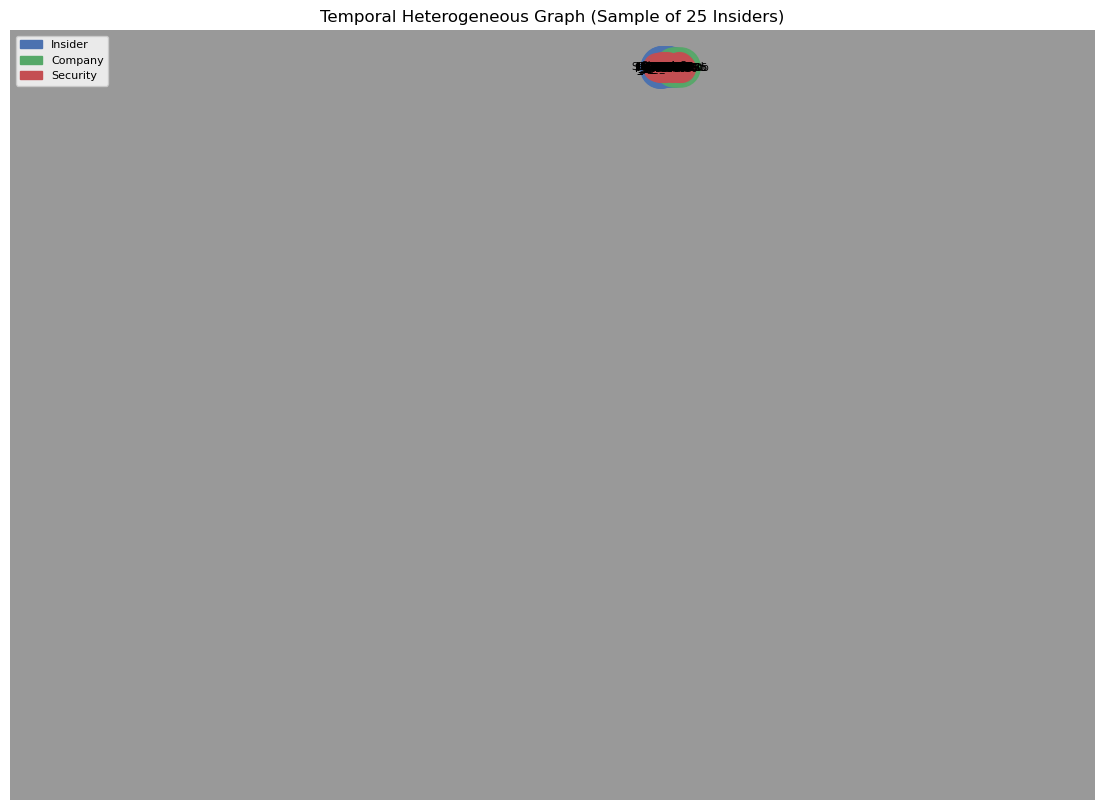

In [4]:
visualize(assoc_small, issues_small, trades_agg_small, id_maps, top_ciks, VIS_LIMIT)